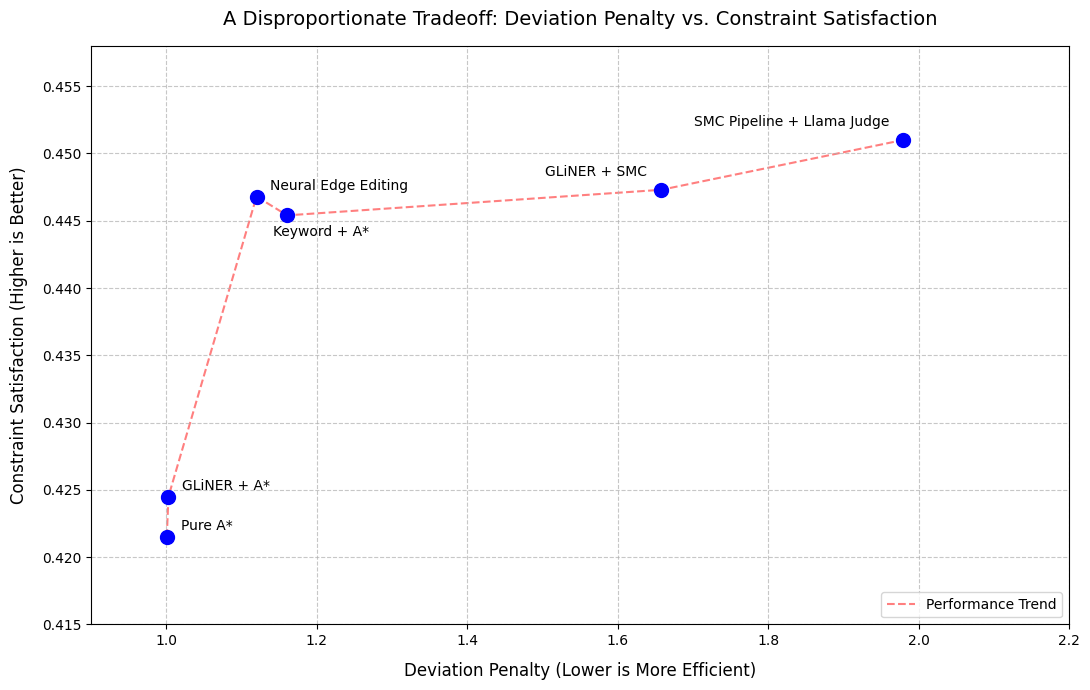

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Data consolidated from the experiment
data = {
    'Method': [
        'Pure A*', 
        'Keyword + A*', 
        'GLiNER + A*', 
        'Neural Edge Editing', 
        'GLiNER + SMC', 
        'SMC Pipeline + Llama Judge'
    ],
    'Deviation_Penalty': [1.0006, 1.1606, 1.0028, 1.1199, 1.6579, 1.9793],
    'Constraint_Satisfaction': [0.4215, 0.4454, 0.4245, 0.4468, 0.4473, 0.4510]
}

df = pd.DataFrame(data)

# Create the Scatter Plot
plt.figure(figsize=(11, 7))
plt.scatter(df['Deviation_Penalty'], df['Constraint_Satisfaction'], color='blue', s=100, zorder=3)

# Annotate each point with the method name
# Added logic to keep labels inside by adjusting limits and using specific alignments
for i, txt in enumerate(df['Method']):
    # For the furthest right point, align text to the left
    if df['Deviation_Penalty'][i] > 1.6:
        ha = 'right'
        offset = (-10, 10)
    
    elif df['Deviation_Penalty'][i] > 1.15:
        ha = 'left'
        offset = (-10, -15)
    # For points near the bottom left, align differently if needed
    else:
        ha = 'left'
        offset = (10, 5)
        
    plt.annotate(txt, (df['Deviation_Penalty'][i], df['Constraint_Satisfaction'][i]), 
                 xytext=offset, textcoords='offset points', fontsize=10, ha=ha, zorder=4)

# Set limits to ensure all labels are well within the frame
plt.xlim(0.9, 2.2)
plt.ylim(0.415, 0.458)

plt.xlabel('Deviation Penalty (Lower is More Efficient)', fontsize=12, labelpad=10)
plt.ylabel('Constraint Satisfaction (Higher is Better)', fontsize=12, labelpad=10)
plt.title('A Disproportionate Tradeoff: Deviation Penalty vs. Constraint Satisfaction', fontsize=14, pad=15)
plt.grid(True, linestyle='--', alpha=0.7, zorder=0)

# Efficiency Frontier line (only for non-dominated or trend-showing points)
df_sorted = df.sort_values('Deviation_Penalty')
plt.plot(df_sorted['Deviation_Penalty'], df_sorted['Constraint_Satisfaction'], 'r--', alpha=0.5, label='Performance Trend', zorder=1)

plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('tradeoff.png')